# Data Science Mini Project

### Student Name:ELAIYARASI E

### Batch:DS AN B03

### Project Title:Customer Churn Prediction Using Machine Learning

### Submission Date:26/09/2026

## 1. Problem Definition

#### 1.1 Business / Real-World Problem Statement

Customer churn is a major challenge for telecom companies, as losing customers can affect revenue and business growth. This project aims to analyze customer information and service usage patterns to identify customers who are likely to churn. Predicting customer churn can help telecom companies take appropriate retention measures and improve customer satisfaction.


#### 1.2 Project Objectives

Analyze customer demographic, service, contract, and billing information.

Identify patterns and factors associated with customer churn.

Perform data preprocessing and feature engineering on customer data.

Build machine learning models to predict customer churn.

Compare multiple classification models using appropriate evaluation metrics.

Select and export a suitable model for deployment.

Deploy the churn prediction model using Flask/FastAPI and Docker.

#### 1.3 Machine Learning Problem Type

Selected Category:

Supervised Learning – Classification

Reason:
The target variable Churn contains two classes — Yes and No. The objective is to predict whether a customer will churn based on their available customer and service-related features.

 ## 2. Dataset Understanding

#### 2.1 Dataset Source

Dataset Source: IBM GitHub Repository

Dataset Name: Telco Customer Churn

Dataset Author/Organization: IBM

Source Link: (https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/refs/heads/master/data/Telco-Customer-Churn.csv)

The dataset contains customer information from a telecommunications service provider. It includes demographic details, services subscribed to, contract information, payment methods, and billing-related information.

The dataset is used to analyze customer behavior and build a machine learning classification model to predict whether a customer is likely to churn.

Dataset file used in the project:

Telco-Customer-Churn.csv

Target variable:

Churn — indicates whether the customer has left the telecom service (Yes) or stayed (No).

#### 2.2 Dataset Description

The Telco Customer Churn dataset contains information about customers of a telecommunications service provider. It includes customer demographic details, subscribed services, contract information, payment methods, and billing-related attributes.

Number of Rows: 7,043 customer records
Number of Columns: 21
Dataset Purpose: To analyze customer characteristics and service usage patterns and predict whether a customer is likely to churn.
Data Collection Source: The dataset is provided through the IBM Telco Customer Churn dataset repository on GitHub. The repository contains the Telco-Customer-Churn.csv file with 7,044 lines including the header, corresponding to 7,043 customer records.
Dataset Description

The dataset is suitable for a supervised classification problem because it contains a Churn target variable with two possible outcomes: Yes and No. The project uses customer-related features to predict whether a customer will leave the telecom service.

#### 2.3 Feature Description

| **Feature Name**   | **Data Type** | **Description**                                                                |
| ------------------ | ------------- | ------------------------------------------------------------------------------ |
| `customerID`       | Categorical   | Unique identification number assigned to each customer.                        |
| `gender`           | Categorical   | Gender of the customer.                                                        |
| `SeniorCitizen`    | Numeric       | Indicates whether the customer is a senior citizen.                            |
| `Partner`          | Categorical   | Indicates whether the customer has a partner.                                  |
| `Dependents`       | Categorical   | Indicates whether the customer has dependents.                                 |
| `tenure`           | Numeric       | Number of months the customer has stayed with the company.                     |
| `PhoneService`     | Categorical   | Indicates whether the customer has phone service.                              |
| `MultipleLines`    | Categorical   | Indicates whether the customer has multiple phone lines.                       |
| `InternetService`  | Categorical   | Type of internet service used by the customer.                                 |
| `OnlineSecurity`   | Categorical   | Indicates whether online security service is subscribed to.                    |
| `OnlineBackup`     | Categorical   | Indicates whether online backup service is subscribed to.                      |
| `DeviceProtection` | Categorical   | Indicates whether device protection service is subscribed to.                  |
| `TechSupport`      | Categorical   | Indicates whether technical support service is subscribed to.                  |
| `StreamingTV`      | Categorical   | Indicates whether the customer subscribes to streaming TV.                     |
| `StreamingMovies`  | Categorical   | Indicates whether the customer subscribes to streaming movies.                 |
| `Contract`         | Categorical   | Type of contract chosen by the customer.                                       |
| `PaperlessBilling` | Categorical   | Indicates whether the customer uses paperless billing.                         |
| `PaymentMethod`    | Categorical   | Payment method used by the customer.                                           |
| `MonthlyCharges`   | Numeric       | Amount charged to the customer each month.                                     |
| `TotalCharges`     | Numeric       | Total amount charged to the customer.                                          |
| `Churn`            | Categorical   | Target variable indicating whether the customer churned (`Yes`) or not (`No`). |


#### 2.4 Target Variable

Target Variable:

* **Name:** `Churn`
* **Description:** Indicates whether a customer has left the telecom service. It contains two classes: `Yes` and `No`.
* **Prediction Goal:** To predict whether a customer is likely to **churn (Yes)** or **not churn (No)** based on the customer's demographic, service, contract, and billing-related features.


## 3. Exploratory Data Analysis (EDA)

#### 3.1 Import Required Libraries

The required Python libraries are imported for data manipulation, numerical analysis, data visualization, and exploratory data analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

#### 3.2 Load Dataset

The Telco Customer Churn dataset is loaded into a Pandas DataFrame for exploratory data analysis.

In [2]:
df = pd.read_csv("../data/Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#### 3.3 Dataset Overview

The dataset overview is performed to understand the number of records, features, column names, data types, and overall structure of the dataset.

In [4]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (7043, 21)

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    


##### Observations

* The dataset contains **7,043 customer records and 21 columns**.
* It includes **18 categorical features and 3 numerical features**.
* `Churn` is the **target variable** for predicting customer churn.
* `TotalCharges` is currently stored as a **string (`str`)**, so it will need appropriate conversion during preprocessing.
* The dataset contains customer demographic, service, contract, payment, and billing information.

Next, we can proceed to **3.4 Missing Value Analysis**.


#### 3.4 Missing Value Analysis

In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

##### Observations

* The dataset contains **no missing values** in any of the 21 columns.
* All **7,043 records** have complete values for the available features.
* Therefore, **no missing-value treatment is required** at this stage.


#### 3.5 Correlation Analysis

In [7]:
df.corr(numeric_only=True)

,SeniorCitizen,tenure,MonthlyCharges
SeniorCitizen,1.000000,0.016567,0.220173
tenure,0.016567,1.000000,0.247900
MonthlyCharges,0.220173,0.247900,1.000000


#### 3.5 Correlation Analysis — Observations

* `MonthlyCharges` has a **positive correlation with tenure (0.248)**, indicating a weak positive relationship.

* `MonthlyCharges` has a **positive correlation with SeniorCitizen (0.220)**, indicating a weak positive relationship.

* `SeniorCitizen` and `tenure` have a **very weak positive correlation (0.017)**.

* Overall, the numerical features show **weak correlations with each other**, with no strong linear relationship observed.


#### 3.6 Visualizations

Visualization 1

Churn Distribution

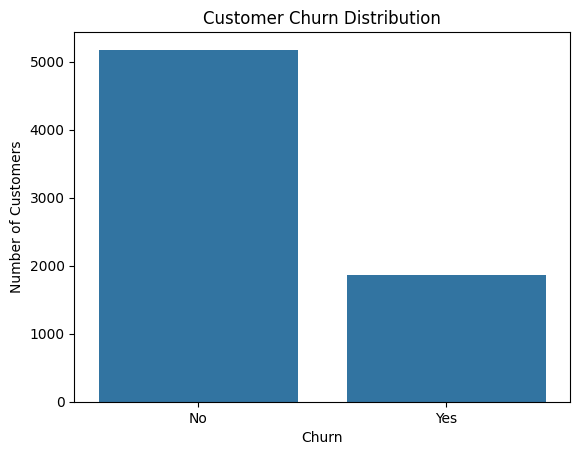

In [8]:
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

observation:

The visualization shows that the number of customers who did not churn (“No”) is much higher than the number of customers who churned (“Yes”). This indicates that the dataset is imbalanced, with more customers belonging to the non-churn class.

#### Visualization 2

Churn by Contract Type

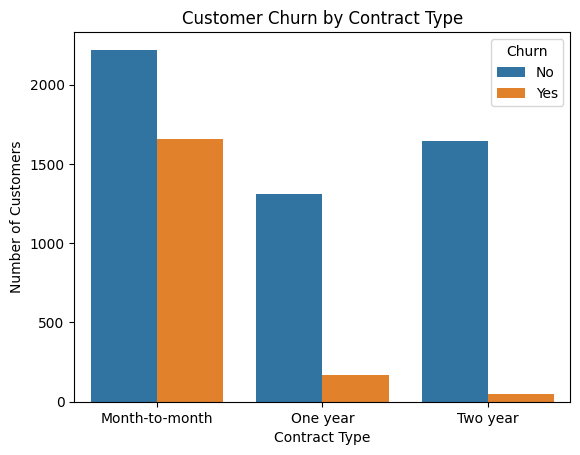

In [9]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.show()

observation:

The visualization shows that month-to-month contracts have the highest number of customers and the highest number of churned customers. Two-year contracts have more customers than one-year contracts, while churn is relatively lower for longer-term contracts.

Visualization 3

Churn by Internet Service

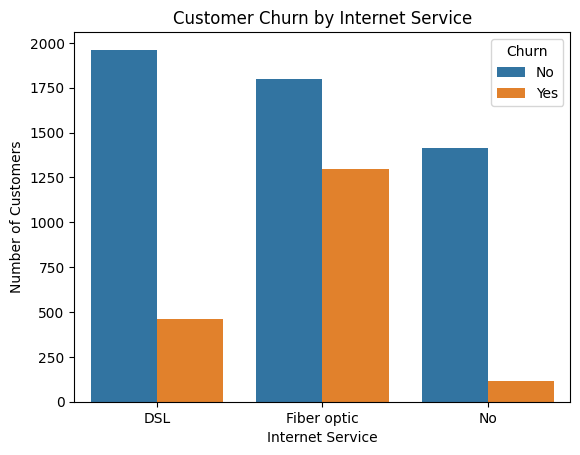

In [10]:
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.show()

Observation:

The visualization shows that customers using Fiber optic internet service have the highest number of customers and also a higher number of churned customers compared with DSL and No internet service.

Visualization 4

Churn by Payment Method

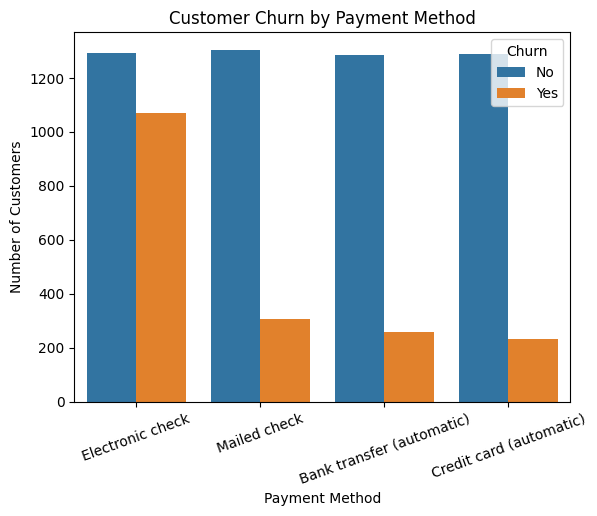

In [11]:
sns.countplot(x="PaymentMethod", hue="Churn", data=df)
plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.show()

Observation

The visualization shows that customers using electronic check have the highest number of churned customers compared with other payment methods. Mailed check and automatic payment methods show comparatively fewer churned customers.

Visualization 5

 Churn by Tenure

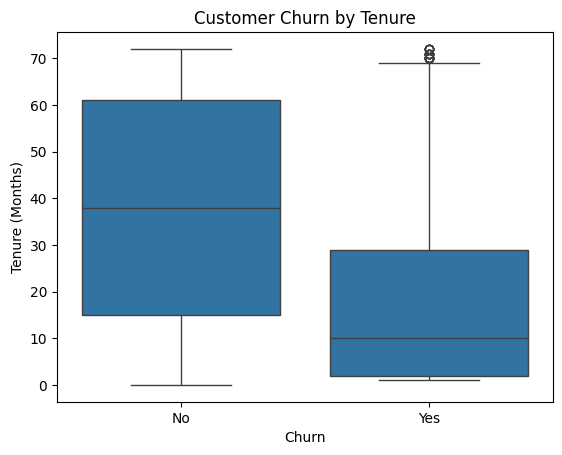

In [12]:
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Customer Churn by Tenure")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()

Observation

The visualization shows that customers who churned generally have lower tenure than customers who did not churn. This indicates that customers with shorter tenure tend to have higher churn.

Visualization 6

 Monthly Charges Distribution

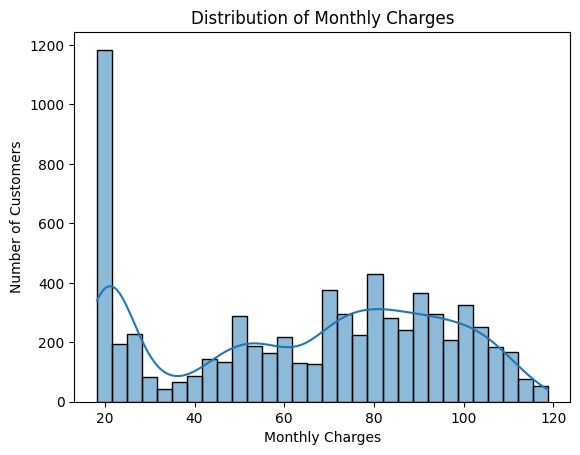

In [13]:
sns.histplot(df["MonthlyCharges"], bins=30, kde=True)
plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.show()

Observation

The histogram shows that monthly charges are distributed across a wide range of values. Most customers have monthly charges in the middle range, while fewer customers have very low or very high monthly charges.

Visualization 7 

Customer Churn by Senior Citizen Status

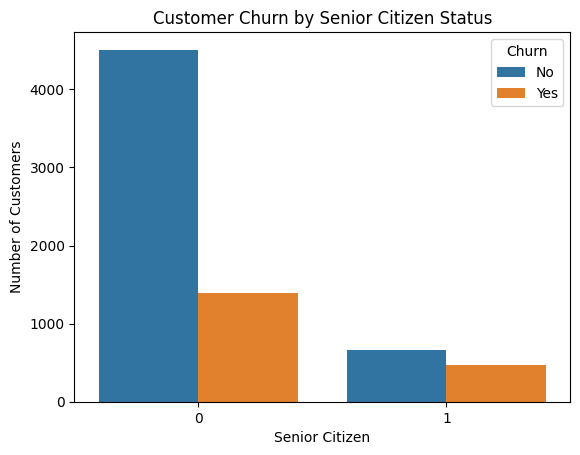

In [14]:
sns.countplot(x="SeniorCitizen", hue="Churn", data=df)
plt.title("Customer Churn by Senior Citizen Status")
plt.xlabel("Senior Citizen")
plt.ylabel("Number of Customers")
plt.show()

Observation

The visualization shows that the number of non-senior customers is much higher than senior customers. Among both groups, non-churned customers are more numerous, while senior customers show a relatively higher proportion of churn compared with non-senior customers.

Visualization 8 

Customer Churn by Monthly Charges

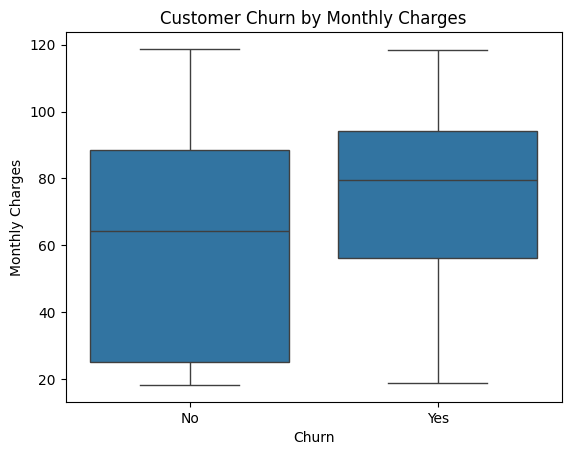

In [15]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Customer Churn by Monthly Charges")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

Observation

The visualization shows that customers who churned generally have higher monthly charges compared with customers who did not churn. This suggests that monthly charges may be associated with customer churn.

 3.7 Key Insights from EDA

* The dataset contains **7,043 customer records and 21 features**.

* The dataset has a **class imbalance**, with more customers who did not churn than customers who churned.

* **Month-to-month contract customers** show a higher number of churned customers compared with longer-term contracts.

* **Fiber optic internet service** has a higher number of churned customers compared with other internet service types.

* Customers using **electronic check** show a higher number of churned customers compared with other payment methods.

* Customers with **lower tenure** generally show higher churn.

* Customers who churned generally have **higher monthly charges**.

* The numerical features show **weak correlations with each other**, with no strong linear relationship observed.

* No missing values were found in the dataset during the initial missing-value analysis.


## 4. Data Preprocessing

4.1 Missing Value Treatment

In [16]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64



### Method Used:

**No imputation required**

### Justification:

> The missing value analysis shows that all 21 columns contain **0 missing values**. Therefore, no missing value imputation method such as mean, median, mode, or `SimpleImputer` is required.


4.2 Duplicate Handling

In [17]:
df.duplicated().sum()

np.int64(0)

### Observation:

> The dataset contains **no duplicate records**. Therefore, no duplicate rows were removed during preprocessing.


4.3 Outlier Detection and Treatment

Boxplot


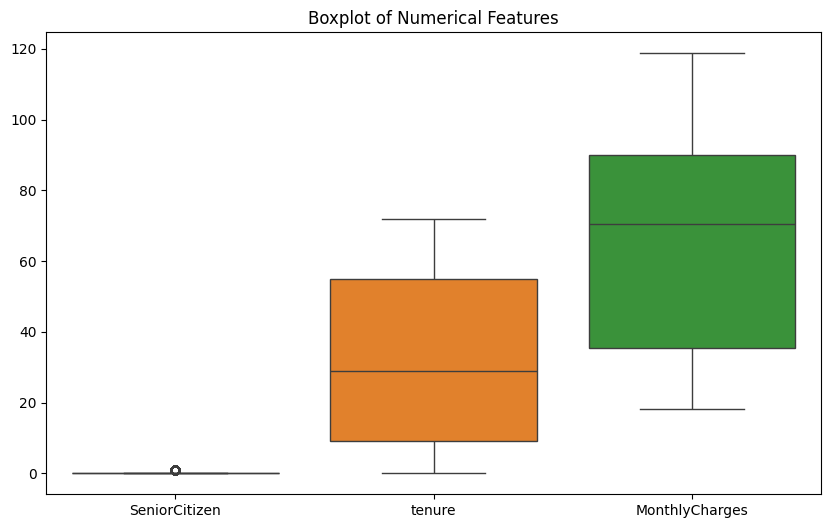

In [18]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[["SeniorCitizen", "tenure", "MonthlyCharges"]])
plt.title("Boxplot of Numerical Features")
plt.show()

IQR Method

In [19]:
Q1 = df[["SeniorCitizen", "tenure", "MonthlyCharges"]].quantile(0.25)
Q3 = df[["SeniorCitizen", "tenure", "MonthlyCharges"]].quantile(0.75)

IQR = Q3 - Q1

outliers = ((df[["SeniorCitizen", "tenure", "MonthlyCharges"]] < (Q1 - 1.5 * IQR)) |
            (df[["SeniorCitizen", "tenure", "MonthlyCharges"]] > (Q3 + 1.5 * IQR))).sum()

print("Outliers in each numerical feature:")
print(outliers)

Outliers in each numerical feature:
SeniorCitizen     1142
tenure               0
MonthlyCharges       0
dtype: int64


Z-Score Method

In [20]:
from scipy.stats import zscore

z_scores = np.abs(zscore(df[["SeniorCitizen", "tenure", "MonthlyCharges"]]))

print("Number of outliers using Z-Score:")
print((z_scores > 3).sum(axis=0))

Number of outliers using Z-Score:
[0 0 0]


Observation:

The IQR method identified 1,142 outliers in SeniorCitizen, while tenure and MonthlyCharges had no outliers. However, SeniorCitizen is a binary categorical indicator (0/1), so these are not meaningful numerical outliers. The Z-score method also detected no outliers. Therefore, no outlier treatment is required.

4.4 Skewness Treatment

Before Transformation

In [21]:
skewness = df[["tenure", "MonthlyCharges"]].skew()
print("Skewness before transformation:")
print(skewness)

Skewness before transformation:
tenure            0.239540
MonthlyCharges   -0.220524
dtype: float64


Log / Square Root Transformation

In [22]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df["TotalCharges_log"] = np.log1p(df["TotalCharges"])

print("Skewness after log transformation:")
print(df["TotalCharges_log"].skew())

Skewness after log transformation:
-0.7430886108265042


Observation:

The skewness values of tenure (0.2395) and MonthlyCharges (-0.2205) are close to zero, indicating that both features are approximately symmetric. The log transformation of TotalCharges resulted in a skewness of -0.7431. Therefore, no further skewness treatment is required for tenure and MonthlyCharges.

4.5 Encoding

Label Encoding

In [23]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df["Churn"] = label_encoder.fit_transform(df["Churn"])

print(df["Churn"].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


One Hot Encoding

In [24]:
df = pd.get_dummies(df, drop_first=True)

print("Shape after encoding:", df.shape)

Shape after encoding: (7043, 7074)


Observation

The binary target variable Churn was label encoded into 0 and 1. The categorical input features were converted into numerical features using one-hot encoding, resulting in 7,074 columns.

4.6 Feature Scaling

Standardization

In [25]:
from sklearn.preprocessing import StandardScaler

Normalization

In [26]:
from sklearn.preprocessing import MinMaxScaler

4.7 Train-Test Split

In [27]:
from sklearn.model_selection import train_test_split

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (5634, 7073)
Testing set: (1409, 7073)


### Observation

> The dataset was divided into **80% training data and 20% testing data**. The training set contains **5,634 records**, while the testing set contains **1,409 records**, with **7,073 features** after encoding. Stratified splitting was used to maintain the class distribution of the target variable.


## 5. Feature Engineering & Feature Selection

5.1 Feature Engineering

Customer Tenure Group feature based on the number of months a customer has stayed with the telecom company.

In [28]:
X_train["TenureGroup"] = pd.cut(
    X_train["tenure"],
    bins=[-1, 12, 24, 48, 60, float("inf")],
    labels=["0-1 Year", "1-2 Years", "2-4 Years", "4-5 Years", "5+ Years"]
)

X_test["TenureGroup"] = pd.cut(
    X_test["tenure"],
    bins=[-1, 12, 24, 48, 60, float("inf")],
    labels=["0-1 Year", "1-2 Years", "2-4 Years", "4-5 Years", "5+ Years"]
)

print(X_train["TenureGroup"].value_counts())

TenureGroup
0-1 Year     1737
2-4 Years    1290
5+ Years     1131
1-2 Years     818
4-5 Years     658
Name: count, dtype: int64


Explanation:

The TenureGroup feature categorizes customers based on how long they have been with the company. This may help the model identify different churn patterns among new, medium-term, and long-term customers.

Observation

The TenureGroup feature categorizes customers based on their tenure. The 0–1 Year group has the highest number of customers (1,737), while the 4–5 Years group has the lowest (658). This feature helps represent customer tenure in meaningful groups for further analysis.

5.2 Correlation-Based Feature Selection

In [29]:
correlation = X_train.select_dtypes(include="number").corrwith(y_train).abs().sort_values(ascending=False)

print("Feature correlation with Churn:")
print(correlation)

Feature correlation with Churn:
tenure              0.345593
TotalCharges_log    0.232193
MonthlyCharges      0.198040
TotalCharges        0.194814
SeniorCitizen       0.145599
dtype: float64


Observation

The correlation analysis shows that tenure has the highest correlation with Churn (0.3456) among the available numerical features. TotalCharges_log (0.2322) and MonthlyCharges (0.1980) show weaker positive correlations. SeniorCitizen has the lowest correlation (0.1456). These features can be considered for further feature selection.

5.3 SelectKBest


In [10]:
numeric_cols = X_train.select_dtypes(include="number").columns

X_train[numeric_cols] = X_train[numeric_cols].fillna(X_train[numeric_cols].median())
X_test[numeric_cols] = X_test[numeric_cols].fillna(X_train[numeric_cols].median())

print("NaN values in X_train:", X_train.isnull().sum().sum())
print("NaN values in X_test:", X_test.isnull().sum().sum())

NaN values in X_train: 0
NaN values in X_test: 0


In [11]:
import pandas as pd

df = pd.read_csv("../data/Telco-Customer-Churn.csv")

print("Dataset Shape:", df.shape)

Dataset Shape: (7043, 21)


In [9]:
from sklearn.model_selection import train_test_split

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (5634, 20)
Testing set: (1409, 20)


In [50]:
from sklearn.feature_selection import SelectKBest, f_classif

numeric_cols = X_train.select_dtypes(include="number").columns

selector = SelectKBest(score_func=f_classif, k=5)

X_train_selected = selector.fit_transform(X_train[numeric_cols], y_train)
X_test_selected = selector.transform(X_test[numeric_cols])

selected_features = numeric_cols[selector.get_support()]

print("Selected Features:")
print(selected_features.tolist())

Selected Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'TotalCharges_log']


### Selected Features

1. `SeniorCitizen`
2. `tenure`
3. `MonthlyCharges`
4. `TotalCharges`
5. `TotalCharges_log`


**Observation:**

> SelectKBest selected all five available numerical features based on their statistical relationship with the target variable `Churn`. These features will be used for further model building.


5.4 Final Feature Set

In [35]:
print("Final Selected Features:")
print(selected_features.tolist())

Final Selected Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'TotalCharges_log']



**Selected Features:**

* `SeniorCitizen`
* `tenure`
* `MonthlyCharges`
* `TotalCharges`
* `TotalCharges_log`

**Justification:**

> These five features were selected using the **SelectKBest** method with the ANOVA F-test (`f_classif`). They were selected based on their statistical relationship with the target variable `Churn` and will be used for the subsequent model-building process.


## 6. Model Building

6.1 Baseline Model

Logistic Regression as the baseline

In [25]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(max_iter=1000, random_state=42)

baseline_model.fit(X_train_selected, y_train)

baseline_predictions = baseline_model.predict(X_test_selected)

print("Baseline model trained successfully.")

Baseline model trained successfully.


6.2 Model 

Model Name:

Decision Tree Classifier

In [13]:
from sklearn.tree import DecisionTreeClassifier

model_1 = DecisionTreeClassifier(random_state=42)

model_1.fit(X_train_selected, y_train)

model_1_predictions = model_1.predict(X_test_selected)

print("Model 1 trained successfully.")

Model 1 trained successfully.


In [16]:
import numpy as np

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges_log"] = np.log1p(df["TotalCharges"])

df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

df = pd.get_dummies(df, drop_first=True)

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_cols = X_train.select_dtypes(include="number").columns

X_train[numeric_cols] = X_train[numeric_cols].fillna(
    X_train[numeric_cols].median()
)

X_test[numeric_cols] = X_test[numeric_cols].fillna(
    X_train[numeric_cols].median()
)

selected_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "TotalCharges_log"
]

X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

print("Selected features prepared successfully.")

Selected features prepared successfully.


6.3 Model 2

Model Name:

Random Forest Classifier

In [17]:
from sklearn.ensemble import RandomForestClassifier

model_2 = RandomForestClassifier(random_state=42)

model_2.fit(X_train_selected, y_train)

model_2_predictions = model_2.predict(X_test_selected)

print("Model 2 trained successfully.")

Model 2 trained successfully.


6.4 Model 3

Model Name:

Support Vector Machine (SVM)


In [18]:
from sklearn.svm import SVC

model_3 = SVC(random_state=42)

model_3.fit(X_train_selected, y_train)

model_3_predictions = model_3.predict(X_test_selected)

print("Model 3 trained successfully.")

Model 3 trained successfully.


6.5 Model 4

Model Name:

K-Nearest Neighbors (KNN)

In [19]:
from sklearn.neighbors import KNeighborsClassifier

model_4 = KNeighborsClassifier()

model_4.fit(X_train_selected, y_train)

model_4_predictions = model_4.predict(X_test_selected)

print("Model 4 trained successfully.")

Model 4 trained successfully.


6.6 Model 5

Model Name:

Gradient Boosting Classifier

In [20]:
from sklearn.ensemble import GradientBoostingClassifier

model_5 = GradientBoostingClassifier(random_state=42)

model_5.fit(X_train_selected, y_train)

model_5_predictions = model_5.predict(X_test_selected)

print("Model 5 trained successfully.")

Model 5 trained successfully.


### Observation

Five classification models were built using the final selected features: Logistic Regression, Decision Tree, Random Forest, Support Vector Machine (SVM), K-Nearest Neighbors (KNN), and Gradient Boosting Classifier. These models will be evaluated and compared using Accuracy, Precision, Recall, F1 Score, and ROC-AUC in the next section to determine their performance on the test dataset.

## 7. Model Evaluation & Comparison

The classification models are evaluated using Accuracy, Precision, Recall, F1 Score, and ROC-AUC.

 7.1 Evaluation Metrics

 Classification Project

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

These metrics are used together to evaluate how well the models identify customers who are likely to churn and customers who are likely to stay.

In [26]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(max_iter=1000, random_state=42)

baseline_model.fit(X_train_selected, y_train)

baseline_predictions = baseline_model.predict(X_test_selected)

print("Baseline model trained successfully.")

Baseline model trained successfully.


In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Baseline - Logistic Regression")
print("Accuracy:", accuracy_score(y_test, baseline_predictions))
print("Precision:", precision_score(y_test, baseline_predictions))
print("Recall:", recall_score(y_test, baseline_predictions))
print("F1 Score:", f1_score(y_test, baseline_predictions))
print("ROC-AUC:", roc_auc_score(y_test, baseline_model.predict_proba(X_test_selected)[:, 1]))

Baseline - Logistic Regression
Accuracy: 0.7920511000709723
Precision: 0.6551724137931034
Recall: 0.4572192513368984
F1 Score: 0.5385826771653544
ROC-AUC: 0.8271655170632153


In [29]:
from sklearn.tree import DecisionTreeClassifier

model_1 = DecisionTreeClassifier(random_state=42)

model_1.fit(X_train_selected, y_train)

model_1_predictions = model_1.predict(X_test_selected)

print("Model 1 predictions created successfully.")

Model 1 predictions created successfully.


In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Model 1 - Decision Tree")
print("Accuracy:", accuracy_score(y_test, model_1_predictions))
print("Precision:", precision_score(y_test, model_1_predictions))
print("Recall:", recall_score(y_test, model_1_predictions))
print("F1 Score:", f1_score(y_test, model_1_predictions))
print("ROC-AUC:", roc_auc_score(y_test, model_1.predict_proba(X_test_selected)[:, 1]))

Model 1 - Decision Tree
Accuracy: 0.7189496096522356
Precision: 0.4701086956521739
Recall: 0.4625668449197861
F1 Score: 0.46630727762803237
ROC-AUC: 0.6467036089798237


In [31]:
from sklearn.ensemble import RandomForestClassifier

model_2 = RandomForestClassifier(random_state=42)

model_2.fit(X_train_selected, y_train)

model_2_predictions = model_2.predict(X_test_selected)

print("Model 2 predictions created successfully.")

Model 2 predictions created successfully.


In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Model 2 - Random Forest")
print("Accuracy:", accuracy_score(y_test, model_2_predictions))
print("Precision:", precision_score(y_test, model_2_predictions))
print("Recall:", recall_score(y_test, model_2_predictions))
print("F1 Score:", f1_score(y_test, model_2_predictions))
print("ROC-AUC:", roc_auc_score(y_test, model_2.predict_proba(X_test_selected)[:, 1]))

Model 2 - Random Forest
Accuracy: 0.7714691270404542
Precision: 0.5928571428571429
Recall: 0.44385026737967914
F1 Score: 0.5076452599388379
ROC-AUC: 0.7763956702575628


In [33]:
from sklearn.svm import SVC

model_3 = SVC(random_state=42)

model_3.fit(X_train_selected, y_train)

model_3_predictions = model_3.predict(X_test_selected)

print("Model 3 predictions created successfully.")

Model 3 predictions created successfully.


In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Model 3 - SVM")
print("Accuracy:", accuracy_score(y_test, model_3_predictions))
print("Precision:", precision_score(y_test, model_3_predictions))
print("Recall:", recall_score(y_test, model_3_predictions))
print("F1 Score:", f1_score(y_test, model_3_predictions))
print("ROC-AUC:", roc_auc_score(y_test, model_3.decision_function(X_test_selected)))


Model 3 - SVM
Accuracy: 0.7345635202271115
Precision: 0.0
Recall: 0.0
F1 Score: 0.0


c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


ROC-AUC: 0.7952607920638611


In [40]:
from sklearn.metrics import roc_auc_score

svm_scores = model_3.decision_function(X_test_selected)

print("Model 3 - SVM ROC-AUC:", roc_auc_score(y_test, svm_scores))

Model 3 - SVM ROC-AUC: 0.7952607920638611


In [35]:
from sklearn.neighbors import KNeighborsClassifier

model_4 = KNeighborsClassifier()

model_4.fit(X_train_selected, y_train)

model_4_predictions = model_4.predict(X_test_selected)

print("Model 4 predictions created successfully.")

Model 4 predictions created successfully.


In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Model 4 - KNN")
print("Accuracy:", accuracy_score(y_test, model_4_predictions))
print("Precision:", precision_score(y_test, model_4_predictions))
print("Recall:", recall_score(y_test, model_4_predictions))
print("F1 Score:", f1_score(y_test, model_4_predictions))
print("ROC-AUC:", roc_auc_score(y_test, model_4.predict_proba(X_test_selected)[:, 1]))

Model 4 - KNN
Accuracy: 0.7643718949609652
Precision: 0.5755395683453237
Recall: 0.42780748663101603
F1 Score: 0.49079754601226994
ROC-AUC: 0.7504120488775221


In [41]:
from sklearn.ensemble import GradientBoostingClassifier

model_5 = GradientBoostingClassifier(random_state=42)

model_5.fit(X_train_selected, y_train)

model_5_predictions = model_5.predict(X_test_selected)

print("Model 5 predictions created successfully.")

Model 5 predictions created successfully.


In [42]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Model 5 - Gradient Boosting")
print("Accuracy:", accuracy_score(y_test, model_5_predictions))
print("Precision:", precision_score(y_test, model_5_predictions))
print("Recall:", recall_score(y_test, model_5_predictions))
print("F1 Score:", f1_score(y_test, model_5_predictions))
print("ROC-AUC:", roc_auc_score(y_test, model_5.predict_proba(X_test_selected)[:, 1]))

Model 5 - Gradient Boosting
Accuracy: 0.794180269694819
Precision: 0.648936170212766
Recall: 0.4893048128342246
F1 Score: 0.5579268292682927
ROC-AUC: 0.8292283448293678


| Model                          | Accuracy | Precision | Recall | F1 Score | ROC-AUC |
| ------------------------------ | -------: | --------: | -----: | -------: | ------: |
| Baseline – Logistic Regression |   0.7921 |    0.6552 | 0.4572 |   0.5386 |  0.8272 |
| Model 1 – Decision Tree        |   0.7189 |    0.4701 | 0.4626 |   0.4663 |  0.6467 |
| Model 2 – Random Forest        |   0.7715 |    0.5929 | 0.4439 |   0.5076 |  0.7764 |
| Model 3 – SVM                  |   0.7346 |    0.0000 | 0.0000 |   0.0000 |  0.7953 |
| Model 4 – KNN                  |   0.7644 |    0.5755 | 0.4278 |   0.4908 |  0.7504 |
| Model 5 – Gradient Boosting    |   0.7942 |    0.6489 | 0.4893 |   0.5579 |  0.8292 |


7.2 Model Comparison Table

In [43]:
import pandas as pd

results = pd.DataFrame([
    ["Baseline - Logistic Regression", 0.7921, 0.6552, 0.4572, 0.5386, 0.8272],
    ["Model 1 - Decision Tree", 0.7189, 0.4701, 0.4626, 0.4663, 0.6467],
    ["Model 2 - Random Forest", 0.7715, 0.5929, 0.4439, 0.5076, 0.7764],
    ["Model 3 - SVM", 0.7346, 0.0000, 0.0000, 0.0000, 0.7953],
    ["Model 4 - KNN", 0.7644, 0.5755, 0.4278, 0.4908, 0.7504],
    ["Model 5 - Gradient Boosting", 0.7942, 0.6489, 0.4893, 0.5579, 0.8292]
], columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"])

display(results)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Baseline - Logistic Regression,0.7921,0.6552,0.4572,0.5386,0.8272
1,Model 1 - Decision Tree,0.7189,0.4701,0.4626,0.4663,0.6467
2,Model 2 - Random Forest,0.7715,0.5929,0.4439,0.5076,0.7764
3,Model 3 - SVM,0.7346,0.0000,0.0000,0.0000,0.7953
4,Model 4 - KNN,0.7644,0.5755,0.4278,0.4908,0.7504
5,Model 5 - Gradient Boosting,0.7942,0.6489,0.4893,0.5579,0.8292


7.3 Best Model Selection

In [45]:
best_model = results.loc[results["ROC-AUC"].idxmax()]

print("Best Model:", best_model["Model"])
print("ROC-AUC:", best_model["ROC-AUC"])
print("F1 Score:", best_model["F1 Score"])
print("Recall:", best_model["Recall"])


Best Model: Model 5 - Gradient Boosting
ROC-AUC: 0.8292
F1 Score: 0.5579
Recall: 0.4893


### Best Model Selection explanation:

Based on the evaluation results, Gradient Boosting achieved the highest ROC-AUC (0.8292), highest Recall (0.4893), and highest F1 Score (0.5579) among the evaluated models. Therefore, Gradient Boosting is selected as the final model for customer churn prediction.

### Strengths

- Captures non-linear relationships between customer features and churn.
- Provides the highest F1 Score and ROC-AUC among the evaluated models.
- Combines multiple weak learners to improve predictive performance.

### Limitations

- More complex than simple models such as Logistic Regression.
- Training can take more time as the number of boosting stages increases.
- The model is less interpretable than Logistic Regression.

7.4 Overfitting / Underfitting Analysis

In [46]:
from sklearn.metrics import accuracy_score

train_predictions = model_5.predict(X_train_selected)
test_predictions = model_5.predict(X_test_selected)

train_accuracy = accuracy_score(y_train, train_predictions)
test_accuracy = accuracy_score(y_test, test_predictions)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)
print("Accuracy Difference:", train_accuracy - test_accuracy)

Training Accuracy: 0.8123890663826766
Testing Accuracy: 0.794180269694819
Accuracy Difference: 0.018208796687857576



### Training Performance

The Gradient Boosting model achieved a training accuracy of **81.24%**.

### Testing Performance

The model achieved a testing accuracy of **79.42%**. The testing performance is reasonably close to the training performance.

### Generalization Capability

The difference between training and testing accuracy is approximately **1.82 percentage points**, indicating a small performance gap. This suggests that the model has good generalization capability and does not show a strong indication of overfitting based on accuracy.

## 8. Deployment

 8.1 Model Export

In [47]:
import pickle

with open("../models/gradient_boosting_model.pkl", "wb") as file:
    pickle.dump(model_5, file)

print("Gradient Boosting model exported successfully.")

Gradient Boosting model exported successfully.




The trained Gradient Boosting classification model was exported using Python's Pickle library.

The saved model file is:

`gradient_boosting_model.pkl`

This exported model will be loaded during deployment to make predictions for new customer data.

## 8.2 API Development

### Technology Used

- Flask
- Python
- Pandas
- Pickle

### API Endpoint

```text
POST /predict

### Sample Request

{

    "SeniorCitizen": 0,

    "tenure": 24,

    "MonthlyCharges": 70.50,

    "TotalCharges": 1692.00,

    "TotalCharges_log": 7.44

}

### Sample Response

{
 
    "prediction": 0

}

Prediction Meaning

0 → Customer is predicted to stay

1 → Customer is predicted to churn

API Description

A Flask-based REST API was developed to deploy the trained Gradient Boosting classification model. The /predict endpoint accepts customer information through a POST request and returns the predicted churn class as a JSON response.

8.3 Docker Containerization

### Dockerfile

The Dockerfile was created in the project root folder to containerize the Flask application.

### Build Command

```bash
docker build -t customer-churn-prediction .


### Run Command
```bash
docker run -p 5000:5000 customer-churn-prediction


### Screenshot Evidence

Docker Build Success

Docker Run Success

API Testing Output

### docker_build_success.png

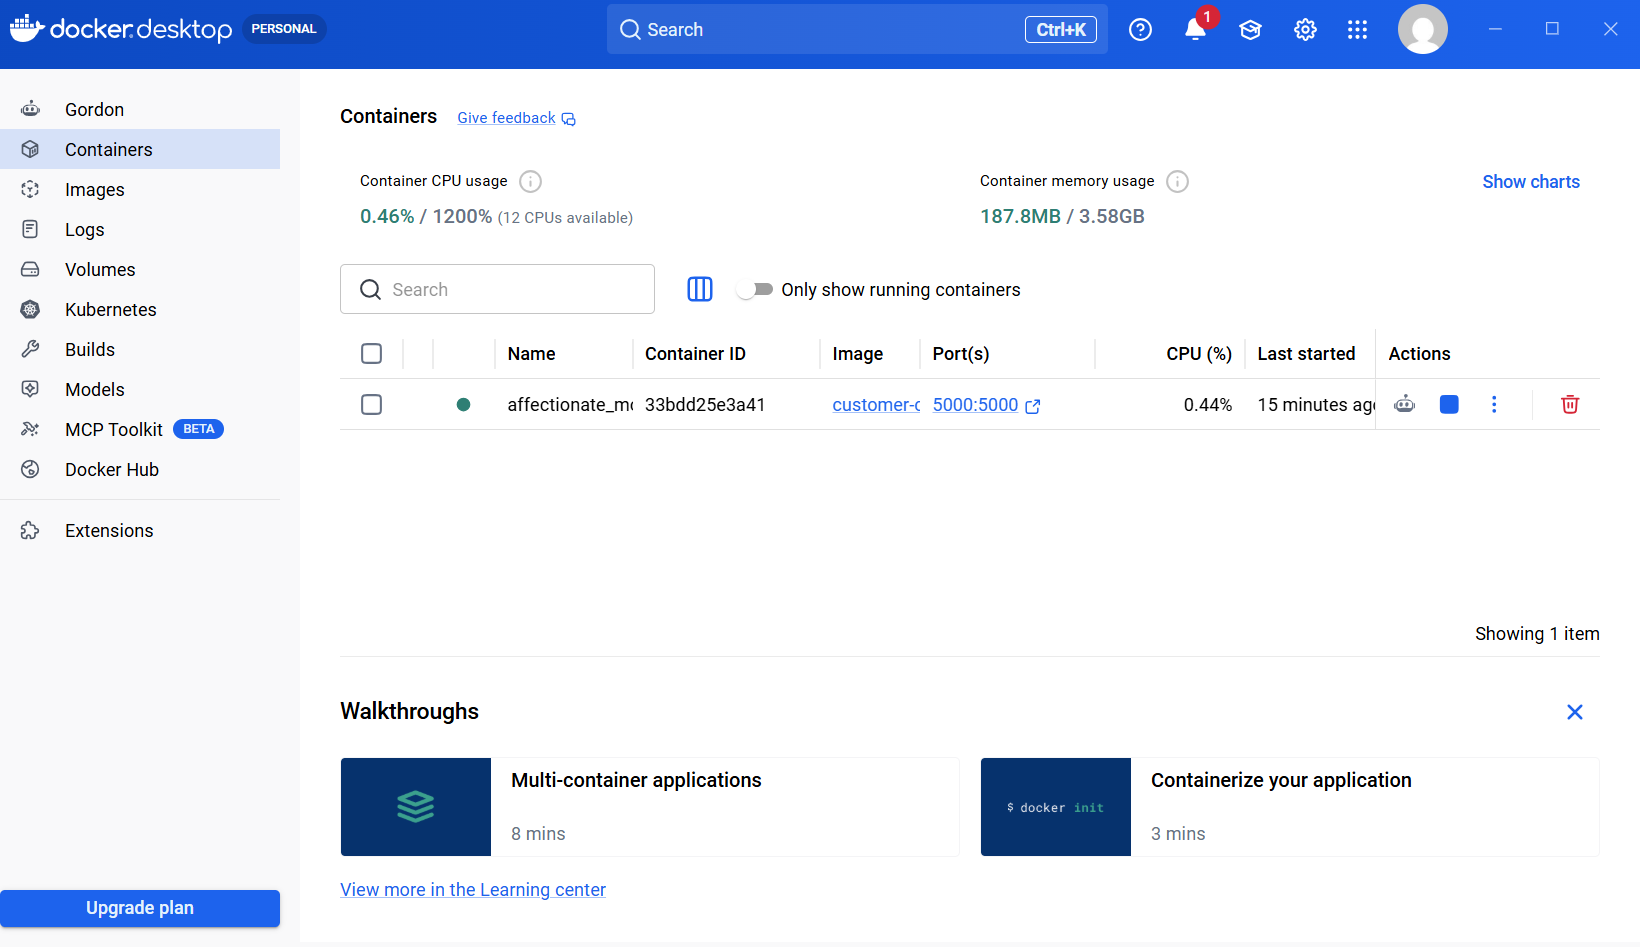

### docker_run_success.png

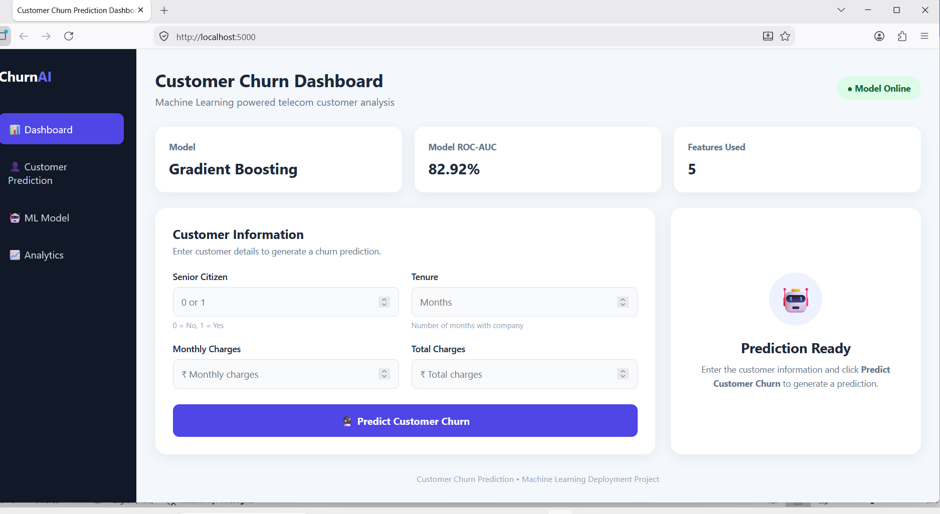

###  api_testing_output.png

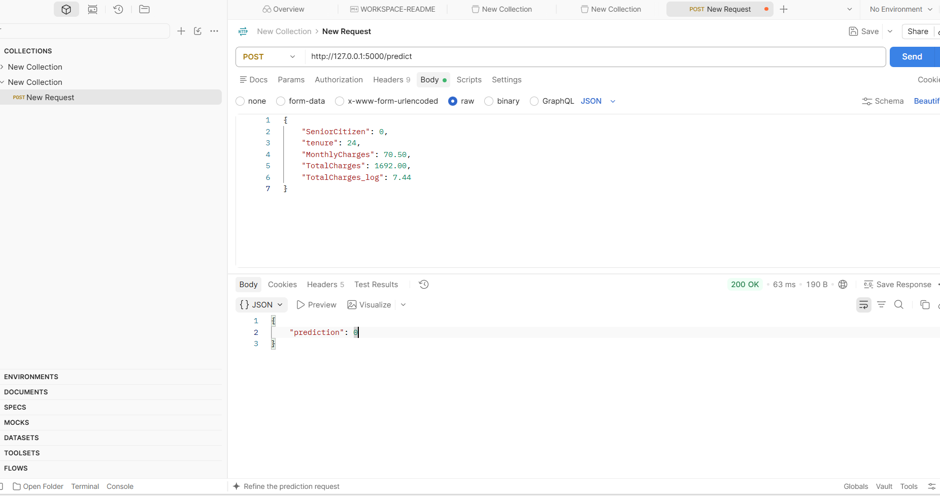

## 9. Conclusion



### Final Findings

This project developed a machine learning-based customer churn prediction system using the Telco Customer Churn dataset.

- The dataset contained **7,043 customer records and 21 features**.
- Exploratory Data Analysis identified important churn-related patterns involving **tenure, monthly charges, contract type, internet service, and payment method**.
- Data preprocessing included missing-value checking, duplicate checking, outlier analysis, skewness treatment, encoding, and train-test splitting.
- **Five features** were selected using SelectKBest for model building.
- Five classification models were evaluated: Logistic Regression, Decision Tree, Random Forest, SVM, KNN, along with Gradient Boosting.
- The **Gradient Boosting model achieved a ROC-AUC of 82.92% and an F1 Score of 55.79%** on the test data.
- The trained model was successfully exported and deployed using **Flask**.
- The Flask API was successfully containerized using **Docker** and tested through Postman.

Overall, the project demonstrates a complete machine learning workflow from data analysis and preprocessing to model building, evaluation, API development, and Docker deployment.

### Business Impact

The customer churn prediction system can help telecom companies identify customers who may be likely to leave the service.

- Helps identify customers who may be at risk of churn.
- Supports targeted customer retention strategies.
- Helps improve customer satisfaction by addressing potential issues early.
- Can help reduce customer loss and protect recurring revenue.
- Provides data-driven insights for customer relationship management.
- The deployed API allows churn predictions to be integrated into business applications.

## Future Improvements

The project can be further improved in the following ways:

- **Additional Data:** Include more customer information such as customer service interactions, complaints, satisfaction scores, and usage patterns.
- **Advanced Algorithms:** Experiment with advanced machine learning and ensemble algorithms to improve prediction performance.
- **Cloud Deployment:** Deploy the application on cloud platforms such as AWS, Azure, or Google Cloud for wider accessibility and scalability.
- **Monitoring and MLOps:** Implement model monitoring to track prediction performance, data changes, and system reliability.
- **Model Retraining Pipeline:** Develop an automated pipeline to periodically retrain the model using newly collected customer data.